## Muraro Pancreatic Dataset: Expression Representation and Preprocessing Considerations

The Muraro dataset was generated using **CEL-seq2**, and the published/processed
expression matrix contains both integer and non-integer values. Approximately
**78.84% of matrix entries are integer-valued and 21.16% are non-integer**.

The supplied matrix was treated as the expression matrix used in established
Muraro analysis workflows rather than assuming that every entry must be an
integer count. The corresponding Bioconductor workflow reads this file as the
count matrix and proceeds with downstream QC and normalization.

The dataset does not contain mitochondrial genes. Consequently, mitochondrial
gene-based QC metrics were not used for this dataset.

The observed gene-detection distribution was relatively high:

- Median genes detected per cell: **4,509**
- 75th percentile: **5,822**
- Many cells contained approximately **2,500–8,000 detected genes**

### Highly Variable Gene Selection

Because the supplied expression matrix contains non-integer values, it does not
meet the raw-count input assumption of the **Seurat v3 HVG method**.

Therefore, highly variable genes for the Muraro dataset were identified using
the **Cell Ranger method**, which is compatible with the supplied expression
representation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)

True

In [3]:
from src import murano_data as md
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import scanpy as sc
import pandas as pd
from src import muraro_preprocessing as mp
from src import clustering as cl
from src import new_evaluation as ev
from src import optimization as opt
from src import visualisation as viz
from src import marker as mk
from src.graph import graph
import src.openAI_llm as lm
from src.agent import cluster_node, evaluate_node, reflection_node, final_selection_node
from src.decision import (OptimizationDecision, FinalExperimentSelection,)
from src.wt_biology_prompts import (
    build_biology_reflection_prompt,
    build_biology_final_selection_prompt,
    MURARO_BIOLOGICAL_CONTEXT,)
from src.experiment_logger import (create_experiment_log,save_experiment_log,add_final_result,)

from langchain_openai.chat_models import ChatOpenAI 
from IPython.display import Image, display

## Muraro Dataset Loading, Reference Annotation and Fixed Preprocessing Pipeline

#### Conversion to AnnData

The Muraro expression matrix was loaded and converted into an AnnData object for
downstream Scanpy-based analysis.

#### Reference Annotations

The published Muraro cell-type annotations were attached to the **3,072 cells**.
These annotations serve as an **independent external reference** for evaluating
the agent-derived clustering.

The reference labels were **not provided to the agent during optimization** and
were used only for post-hoc validation and biological interpretation.

#### Reference Annotation Preparation

Of the 3,072 cells:

- **946 cells** had no published reference label.
- **4 cells** were labelled as `unclear`.
- The remaining cells had usable published cell-type annotations.

For reference-based quantitative evaluation, only cells with a usable reference
annotation were included.

**Important:** The agent still performs clustering on the full dataset available
to it. The reference labels are used only afterward to assess whether cells
assigned to the same Leiden cluster tend to correspond to the same independently
published biological cell type.

In [4]:
muraro = md.load_muraro_expression()

muraro_annotations = md.load_muraro_annotations()

muraro = md.attach_reference_annotations(
    muraro,
    muraro_annotations
)

# Preprocess first
muraro_processed = mp.run_preprocessing_pipeline(
    muraro.copy()
)

# Then create evaluation subset from processed data
muraro_eval = md.get_evaluation_subset(
    muraro_processed
)

# print("Processed:")
#print(muraro_processed)

# print("Evaluation:")
#print(muraro_eval)

Running Muraro QC...
Running normalization...
Running PCA...
Finished Muraro preprocessing.


In [5]:
print(muraro_processed.shape)
print(muraro_processed.obs_names[:5])
print(muraro_processed.var_names[:5])

(2680, 2000)
Index(['D28-1_1', 'D28-1_2', 'D28-1_3', 'D28-1_4', 'D28-1_5'], dtype='object')
Index(['A1BG-AS1__chr19', 'A1CF__chr10', 'A2M__chr12', 'AADAC__chr3',
       'ABCA17P__chr16'],
      dtype='object')


In [6]:
print(muraro_annotations.shape)
display(muraro_annotations.head())

(3072, 2)


,cell_id,label
0,D28-1_1,alpha
1,D28-1_2,endothelial
2,D28-1_3,delta
3,D28-1_4,beta
4,D28-1_5,unclear


In [7]:
print("Expression cells:", muraro.shape[1])
print("Annotation cells:", muraro_annotations.shape[0])
print(
    "All cell IDs match:",
    set(muraro.obs_names) == set(muraro_annotations["cell_id"])
)

Expression cells: 19140
Annotation cells: 3072
All cell IDs match: True


In [10]:
print(muraro_processed.obs["cell_type_reference"].value_counts(dropna=False))

cell_type_reference
alpha          812
NaN            554
beta           448
duct           245
acinar         219
delta          193
pp             101
mesenchymal     80
endothelial     21
unclear          4
epsilon          3
Name: count, dtype: int64


In [11]:
print(muraro_eval.obs["cell_type_reference"].value_counts(dropna=False))

cell_type_reference
alpha          812
beta           448
duct           245
acinar         219
delta          193
pp             101
mesenchymal     80
endothelial     21
epsilon          3
Name: count, dtype: int64


## Agent State Setup
The state acts as the agent's shared memory. Technically, LangGraph simply gives every node the same shared memory. Each node:

+ reads what it needs
+ updates what changed
+ returns the updated state

In this setup, it stores the dataset, current parameters, evaluation metrics, experiment history, and optimization progress, allowing each node in the LangGraph workflow to access the information it needs and update it as the optimization proceeds.


In [31]:
agent_adata = muraro_processed.copy()

In [32]:
experiment_log = create_experiment_log(
    experiment_id="EXP-034b",
    dataset="Muraro",
    method="agentic_biology",
    condition="biology",
    agent_version="v0.6-reproducibility",
    llm_seed=lm.LLM_SEED,
    change=(
        "Applied the existing agentic optimization framework to the "
        "Muraro human pancreas scRNA-seq dataset as an external "
        "generalization experiment."
    ),
    reason_for_change=(
        "To reduce the number of biological infromation the LLM gets"
    ),
)

In [33]:
state = {
    "messages": [],

    "adata": agent_adata,

    "parameters": {
        "n_neighbors": 15,
        "resolution": 1.0,
        "n_pcs": 20,
    },

    "condition": "biology",

    "metrics": {},

    "history": [],

    "experiment_log": experiment_log,

    "iteration": 0,

    "decision": "continue",

    "reason": "",

    "evaluated_configs": [],

    "clustering_time": 0.0,

    "evaluation_time": 0.0,

    "llm_decision_time": 0.0,

    "selected_iteration": None,

    "best_experiment": None,

    "final_selection_reason": None,

    "final_selection_time": 0.0,
}

### Run Agentic Optimization

The following cell executes the agentic optimization workflow using the specified initial state and saves the resulting experiment log.

The agent will iteratively:
- run clustering,
- evaluate the clustering,
- request an LLM reflection/parameter decision,
- continue until the exploration budget is reached or the LLM decides to stop,
- and finally select the preferred experiment from the completed history.


In [34]:
result = graph.invoke(state)

save_experiment_log(result["experiment_log"])


CURRENT EVALUATION
Clusters: 19
Silhouette: 0.1732
DBI: 1.6796
WC-dispersion: 572764.1250
Banfield-Raftery: 13277.4697

LLM PROMPT

You are an expert in single-cell RNA-seq clustering optimization.

Your objective is to explore clustering parameters and identify
parameter configurations that provide strong overall clustering
evidence while avoiding unnecessary over-fragmentation or
under-clustering.

The optimization should balance potential improvement against the
cost of additional experiments.

BIOLOGY-INFORMED EXPERIMENTAL CONDITION:

This is a biology-informed clustering optimization experiment.

The optimization uses three sources of information:

1. intrinsic clustering metrics,
2. cluster structure, and
3. limited biological evidence from marker genes.

These sources of information have different roles.

Intrinsic clustering metrics are the primary quantitative evidence.

Cluster structure is secondary structural evidence used to interpret
the clustering solution.

Marker gene

PosixPath('experiments/EXP-034b.json')

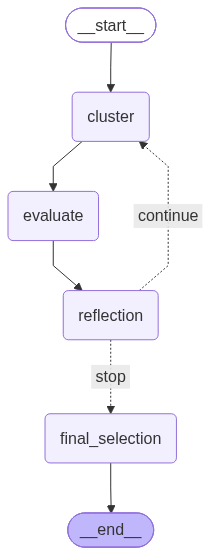

In [20]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
for experiment in result["history"]:
    print("\nIteration:", experiment["iteration"])
    print("Parameters:", experiment["parameters"])
    print("Metrics:", experiment["metrics"])

In [22]:
best_experiment = result["history"][2]

best_params = best_experiment["parameters"]

print(best_params)

{'n_neighbors': 15, 'resolution': 0.6, 'n_pcs': 20}


In [23]:
murano_data_best = cl.run_clustering(
    muraro_processed.copy(),
    n_neighbors=best_params["n_neighbors"],
    resolution=best_params["resolution"],
    n_pcs=best_params["n_pcs"],)

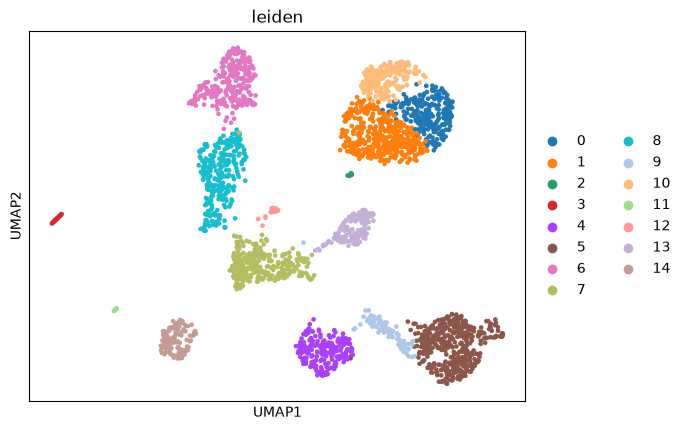

In [24]:
viz.plot_umap(murano_data_best, color="leiden")

In [25]:
ev.get_cluster_summary(murano_data_best)

{'0': 248,
 '1': 423,
 '2': 6,
 '3': 22,
 '4': 196,
 '5': 407,
 '6': 261,
 '7': 280,
 '8': 277,
 '9': 83,
 '10': 193,
 '11': 10,
 '12': 21,
 '13': 142,
 '14': 111}